# DAY 2 논문 기반 배터리 수명 예측 개발 및 비교
울산캠퍼스 2반 · U040 김가연 · U067 이준희

**범위:** Regression. Batch 1 학습·내부 검증, Batch 2 필수 테스트만 수행한다.
**논문:** Severson et al. (2019), [Nature Energy 원문](https://www.nature.com/articles/s41560-019-0356-8), [저자 공개 PDF](https://web.mit.edu/braatzgroup/Severson_NatureEnergy_2019.pdf).
**이번 수정:** 논문의 모델·피처·Target·평가 조건과 비교할 수 있게 처음부터 재구성했다. 본문 Table 1(p.386), Machine-learning approach(p.384), Methods(p.389)를 확인했다.
**평가 이력:** 이전 버전에서 Batch 2 결과를 확인했다. 이번 모델 후보 확장은 논문 확인에 따른 재분석이며 새롭게 봉인된 미관측 테스트라고 주장하지 않는다. 이번 후보의 선택에는 Batch 1 개발용 CV만 사용하고 기존 Hold-out·정책 분할을 유지한다.


## 1 논문의 방법과 비교 기준
- 논문은 초기 100사이클 피처로 로그 수명을 예측하는 Elastic Net 회귀를 사용한다.
- Variance: ΔQ100−10의 로그분산 1개. Discharge: 방전 후보 13개 중 6개 선택. Full: 전체 후보 20개 중 9개 선택.
- Train 41셀, Primary test 43셀. 원문은 수명 범위를 포괄하는 분할과 4-fold CV·Monte Carlo sampling을 사용했다. 이는 과제의 Batch 1→Batch 2 분할과 동일하지 않다.
- 본문의 mean percent error는 절대 상대오차 평균인 MAPE와 같은 수식이다. 원문의 Train은 학습 적합 오차이며 과제의 Train CV와 다른 지표 구성이다.
- 초록의 9.1%는 과제의 대표 목표로 유지한다. Table 1의 각 모델 Primary test값과는 별도로 비교한다.
- 괄호 값은 특정 이상 셀 1개를 제외했을 때의 결과다. 우리의 오차 큰 셀은 삭제하지 않는다.

보충자료의 전체 후보 정의와 라이선스가 필요한 원래 모델링 코드를 확보하지 못했으므로, 확장 피처 조합은 **논문 아이디어를 적용한 별도 구현**이다. 논문의 Discharge·Full 6/9개 피처를 정확히 복제했다고 표현하지 않는다.


## 2 환경 설정
라이브러리와 고정 seed를 불러온다. 출력은 재현 환경을 보여준다.

In [1]:
from pathlib import Path
import hashlib, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn, joblib
from IPython.display import display
from sklearn.base import clone
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error

SEED = 42
HOLDOUT_RATIO = 0.25   # 정책 그룹의 약 25%; 실제 셀 수 비율은 조금 다를 수 있음
CV_FOLDS = 4

TARGET_MAPE = 9.1     # 과제에서 제공한 비교 기준(%)
print('scikit-learn:', sklearn.__version__)
print('seed:', SEED, '| evaluation: Batch1 / Batch2 only')

scikit-learn: 1.9.1
seed: 42 | evaluation: Batch1 / Batch2 only


**환경 해석:** seed=42를 고정한다. 모델 개발은 현재 표시한 패키지 버전에서 실행했다.

## 3 데이터와 논문 아이디어 피처 구성
**역할:** 기존 확정 라벨과 ΔQ는 유지하고 cycle 2 용량·초기 최대 증가·초기 기울기를 계산한다. 추가 신호는 온도·IR 변화·충전시간이다.
**결과:** 36개 학습, 39개 테스트 셀과 피처별 결측 수를 확인한다. B/C는 별도 구현의 5/8개 후보 조합이며 논문의 13/20개 후보를 그대로 재현한 조합이 아니다.

In [2]:
# 노트북 실행 디렉터리 또는 상위 디렉터리에서 프로젝트를 찾는다.
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'processed/day1_final_features.csv').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('프로젝트 폴더에서 노트북을 열고 processed/day1_final_features.csv를 확인하세요.')
DATA_PATH = ROOT / 'processed/day1_final_features.csv'
OUT = ROOT / 'output/day2'
OUT.mkdir(parents=True, exist_ok=True)
DATA_HASH = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
raw = pd.read_csv(DATA_PATH)
# 기존 EDA 라벨 처리와 ΔQ를 유지하고 방전/추가 신호 피처를 명시적으로 계산한다.
raw = raw.loc[raw.batch.isin(['Batch1','Batch2'])].copy()
raw['delta_q_log_abs_min'] = np.log10(np.abs(raw['delta_q_min']).clip(lower=1e-12))
summary_hashes={}
extra=[]
for batch,file in [('Batch1','batch1_summary.csv.gz'),('Batch2','batch2_summary.csv.gz')]:
    path=ROOT/'processed'/file
    summary_hashes[file]=hashlib.sha256(path.read_bytes()).hexdigest()
    summary=pd.read_csv(path)
    for cid,g in summary.groupby('cell_id'):
        # 초기 100사이클만 사용한다. 제공 Summary의 기존 QD 불연속 기록 처리를 유지한다.
        early=g.loc[g.cycle.between(2,100)].sort_values('cycle')
        q2=early.loc[early.cycle.eq(2),'QD']
        assert len(q2)==1, f'{batch} cell {cid}: cycle 2 missing'
        extra.append({'batch':batch,'cell_id':cid,'qd_cycle2':float(q2.iloc[0]),
                      'qd_max_minus_cycle2':float(early.QD.max()-q2.iloc[0]),
                      'qd_slope_cycle2_100':float(np.polyfit(early.cycle,early.QD,1)[0])})
raw=raw.merge(pd.DataFrame(extra),on=['batch','cell_id'],validate='one_to_one')
FEATURE_SETS={
    'A_variance':['delta_q_log_variance'],
    'B_discharge_adapted':['delta_q_log_variance','delta_q_log_abs_min','qd_cycle2','qd_max_minus_cycle2','qd_slope_cycle2_100'],
    'C_signals_adapted':['delta_q_log_variance','delta_q_log_abs_min','qd_cycle2','qd_max_minus_cycle2','qd_slope_cycle2_100','tavg_mean_100','ir_change_100','chargetime_mean_100'],
    'D_delta_current':['delta_q_log_variance','charge_I_qw_100'],
    'E_delta_chargetime':['delta_q_log_variance','chargetime_mean_100'],
}
FEATURES = list(dict.fromkeys(x for xs in FEATURE_SETS.values() for x in xs))
assert not raw.duplicated(['batch', 'cell_id']).any(), '셀 ID 중복 확인 필요'
assert {'batch','cell_id','cycle_life','charging_policy',*FEATURES}.issubset(raw.columns)
print('입력:', DATA_PATH.relative_to(ROOT))
print('결과:', OUT.relative_to(ROOT))
display(raw.groupby('batch').agg(total_cells=('cell_id','size'), labeled_cells=('cycle_life','count')))
if 'reason' in raw:
    display(raw.groupby(['batch','reason'], dropna=False).size().rename('cells').reset_index())
valid = raw.loc[np.isfinite(raw['cycle_life']) & (raw['cycle_life'] > 0)].copy()
assert valid.groupby('batch').size().to_dict() == {'Batch1':36,'Batch2':39}, '최종 라벨 처리 기준과 다릅니다.'
b1 = valid.loc[valid.batch == 'Batch1'].reset_index(drop=True)
b2 = valid.loc[valid.batch == 'Batch2'].reset_index(drop=True)

assert b1.charging_policy.notna().all(), '정책 그룹 누락 확인 필요'
display(valid.groupby('batch')[FEATURES].agg(lambda s: s.isna().sum()).rename_axis('missing feature counts'))
raw.to_csv(OUT/'model_input_features.csv',index=False)
(OUT/'feature_sets.json').write_text(json.dumps(FEATURE_SETS,ensure_ascii=False,indent=2))
print('CV 후보 피처 그룹:', {k:len(v) for k,v in FEATURE_SETS.items()})


입력: processed/day1_final_features.csv
결과: output/day2
CV 후보 피처 그룹: {'A_variance': 1, 'B_discharge_adapted': 5, 'C_signals_adapted': 8, 'D_delta_current': 2, 'E_delta_chargetime': 2}


,total_cells,labeled_cells
batch,,
Batch1,46,36
Batch2,47,39


,batch,reason,cells
0,Batch1,provided_label,36
1,Batch1,unfinished_or_continuation_unavailable,10
2,Batch2,missing_target,8
3,Batch2,provided_label,39


,delta_q_log_variance,delta_q_log_abs_min,qd_cycle2,qd_max_minus_cycle2,qd_slope_cycle2_100,tavg_mean_100,ir_change_100,chargetime_mean_100,charge_I_qw_100
missing feature counts,,,,,,,,,
Batch1,0,0,0,0,0,0,0,0,0
Batch2,0,0,0,0,0,0,0,0,0


**데이터 해석:** 확정 수명은 Batch 1 36개, Batch 2 39개다. 입력은 초기 100사이클 이하에서만 계산한다. B 조합은 방전 피처 5개, C 조합은 여기에 온도·IR 변화·충전시간을 더한 8개 후보이며 원논문의 13/20개 후보 정의를 그대로 구현한 것은 아니다. 출력 파일에서 전체 피처 정의와 셀별 입력값을 확인할 수 있다.

## 4 기존 정책 그룹 Hold-out 유지
**역할:** 기존 셀·정책 분할을 재사용하고 중복을 검사한다. CV와 Hold-out 결과에 맞춰 seed를 바꾸지 않는다.

In [3]:
SPLIT_PATH = OUT / 'batch1_split.csv'
SPLIT_META = OUT / 'batch1_split_metadata.json'
if SPLIT_PATH.exists():
    meta = json.loads(SPLIT_META.read_text())
    assert meta['data_sha256'] == DATA_HASH, '데이터 변경: 기존 분할과 평가 이력을 먼저 검토하세요.'
    assert meta['seed'] == SEED and meta['holdout_ratio'] == HOLDOUT_RATIO, '기존 분할과 설정이 다릅니다.'
    saved = pd.read_csv(SPLIT_PATH)
    b1 = b1.merge(saved[['cell_id','split']], on='cell_id', validate='one_to_one')
    assert len(b1) == 36 and b1['split'].isin(['development','holdout']).all()
else:
    splitter = GroupShuffleSplit(n_splits=1, test_size=HOLDOUT_RATIO, random_state=SEED)
    dev_idx, hold_idx = next(splitter.split(b1, groups=b1.charging_policy))
    b1['split'] = 'development'
    b1.loc[hold_idx, 'split'] = 'holdout'
    b1[['batch','cell_id','charging_policy','split']].to_csv(SPLIT_PATH, index=False)
    SPLIT_META.write_text(json.dumps({'data_sha256':DATA_HASH,'seed':SEED,'holdout_ratio':HOLDOUT_RATIO}, indent=2))
dev = b1.loc[b1.split == 'development'].reset_index(drop=True)
hold = b1.loc[b1.split == 'holdout'].reset_index(drop=True)
assert set(dev.charging_policy).isdisjoint(set(hold.charging_policy))
display(b1.groupby('split').agg(cells=('cell_id','size'), policies=('charging_policy','nunique')))
display(b1[['cell_id','charging_policy','split']].sort_values(['split','charging_policy']))
print('수명값으로 분할을 다시 고르지 않습니다. 테스트는 아직 평가하지 않습니다.')

수명값으로 분할을 다시 고르지 않습니다. 테스트는 아직 평가하지 않습니다.


,cells,policies
split,,
development,28,15
holdout,8,5


,cell_id,charging_policy,split
3,9,5.4C(40%)-3.6C,development
4,11,5.4C(50%)-3C,development
7,16,5.4C(60%)-3.6C,development
8,17,5.4C(60%)-3.6C,development
5,14,5.4C(60%)-3C,development
6,15,5.4C(60%)-3C,development
9,18,5.4C(70%)-3C,development
10,19,5.4C(70%)-3C,development
11,20,5.4C(80%)-5.4C,development
12,21,5.4C(80%)-5.4C,development


**분할 해석:** 개발용 28개 셀·15개 정책, Hold-out 8개 셀·5개 정책이다. 이전 분할을 그대로 유지했고 정책 겹침이 없다.

## 5 개발용 4-fold 그룹 CV
**역할:** 모든 후보가 같은 fold를 사용하고 같은 정책은 학습과 검증에 겹치지 않게 한다.

In [4]:
n_splits = min(CV_FOLDS, dev.charging_policy.nunique())
assert n_splits >= 2
cv = GroupKFold(n_splits=n_splits)
folds = list(cv.split(dev, groups=dev.charging_policy))
fold_info = []
for k,(tr,va) in enumerate(folds,1):
    assert set(dev.iloc[tr].charging_policy).isdisjoint(set(dev.iloc[va].charging_policy))
    assert len(va) >= 2
    fold_info.append({'fold':k,'train_cells':len(tr),'valid_cells':len(va),
                      'train_policies':dev.iloc[tr].charging_policy.nunique(),
                      'valid_policies':dev.iloc[va].charging_policy.nunique()})
display(pd.DataFrame(fold_info))

,fold,train_cells,valid_cells,train_policies,valid_policies
0,1,20,8,11,4
1,2,21,7,11,4
2,3,21,7,11,4
3,4,22,6,12,3


**CV 해석:** 개발용 28개 셀의 4개 정책 그룹 fold다. Hold-out과 테스트는 후보 비교에 사용하지 않았다.

## 6 후보와 학습 규칙
**역할:** 논문과 같은 Elastic Net + 로그 Target 조합을 포함해 원 Target, Ridge, 얕은 트리도 같은 CV에서 비교한다. 전처리는 Pipeline으로 학습 fold 안에서만 적합한다.
**선택 기준:** 이번 분석은 평균 CV MAPE가 가장 낮은 후보를 선택하고, 동률이면 fold 편차가 작은 후보를 우선한다. 이 기준을 테스트 계산 전에 정한다.

In [5]:
def metrics(y_true, y_pred):
    assert np.isfinite(y_pred).all(), '비정상 예측값 확인'
    return {'MAPE_pct':mean_absolute_percentage_error(y_true,y_pred)*100,
            'MAE_cycles':mean_absolute_error(y_true,y_pred),
            'RMSE_cycles':np.sqrt(mean_squared_error(y_true,y_pred))}

specs = [{'id':'Dummy_median','model':'Dummy','feature_set':'A_variance','target':'raw','params':{}}]
for fs in FEATURE_SETS:
    for target in ['raw','log10']:
        for alpha in [0.1,1.0,10.0]:
            specs.append({'model':'Ridge','feature_set':fs,'target':target,'params':{'alpha':alpha}})
        for alpha in [0.001,0.01,0.1]:
            for ratio in [0.1,0.5,0.9]:
                specs.append({'model':'ElasticNet','feature_set':fs,'target':target,'params':{'alpha':alpha,'l1_ratio':ratio}})
        for depth in [2,3]:
            specs.append({'model':'RandomForest','feature_set':fs,'target':target,'params':{'max_depth':depth}})
        for depth in [1,2]:
            specs.append({'model':'GradientBoosting','feature_set':fs,'target':target,'params':{'max_depth':depth}})
for i,spec in enumerate(specs):
    spec.setdefault('id',f"{spec['model']}_{spec['feature_set']}_{spec['target']}_{i:03d}")
spec_by_id = {s['id']:s for s in specs}

def make_estimator(spec):
    name,p = spec['model'],spec['params']
    if name == 'Dummy': model = DummyRegressor(strategy='median')
    elif name == 'Ridge': model = Ridge(**p)
    elif name == 'ElasticNet': model = ElasticNet(**p,max_iter=50000,random_state=SEED)
    elif name == 'RandomForest':
        model = RandomForestRegressor(**p,n_estimators=150,min_samples_leaf=3,random_state=SEED,n_jobs=1)
    elif name == 'GradientBoosting':
        model = GradientBoostingRegressor(**p,n_estimators=100,learning_rate=0.03,min_samples_leaf=3,random_state=SEED)
    else: raise ValueError(name)
    pipe = Pipeline([('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler()),('model',model)])
    # Target 변환·복원은 모델 내부에서 수행하며 평가는 항상 원래 사이클 단위입니다.
    if spec['target'] == 'log10':
        return TransformedTargetRegressor(regressor=pipe,func=np.log10,inverse_func=lambda x: np.power(10.,x),check_inverse=True)
    return pipe
print('후보:',len(specs),'| folds:',len(folds),'| CV 학습 횟수:',len(specs)*len(folds))

후보: 161 | folds: 4 | CV 학습 횟수: 644


**후보 해석:** 161개 후보를 4개 fold에서 총 644번 학습했다. 원 Target과 로그 Target을 함께 비교하고 Elastic Net의 L1 비율도 0.1/0.5/0.9로 비교했다. 로그 Target 모델도 사이클 단위로 복원한 예측의 MAPE로 선택한다.

## 7 후보 CV 비교
**역할:** Batch 1 개발용만 사용해 설정과 피처 조합을 비교한다. 평균 MAPE가 낮을수록 좋고 표준편차는 fold 간 변동이다.

In [6]:
cv_rows, fold_rows = [], []
start = time.perf_counter()
for i,spec in enumerate(specs,1):
    cols = FEATURE_SETS[spec['feature_set']]
    scores = []
    for k,(tr,va) in enumerate(folds,1):
        est = make_estimator(spec)
        est.fit(dev.iloc[tr][cols], dev.iloc[tr].cycle_life)
        score = metrics(dev.iloc[va].cycle_life, est.predict(dev.iloc[va][cols]))
        scores.append(score)
        fold_rows.append({'candidate_id':spec['id'],'fold':k,**score})
    ss = pd.DataFrame(scores)
    cv_rows.append({'candidate_id':spec['id'],'model':spec['model'],
                    'feature_set':spec['feature_set'],'target':spec['target'],
                    'params':json.dumps(spec['params']),
                    'CV_MAPE_mean':ss.MAPE_pct.mean(),'CV_MAPE_std':ss.MAPE_pct.std(ddof=1),
                    'CV_MAE':ss.MAE_cycles.mean(),'CV_RMSE':ss.RMSE_cycles.mean()})
    if i % 10 == 0: print(f'{i}/{len(specs)} 완료')
cv_results = pd.DataFrame(cv_rows).sort_values(['CV_MAPE_mean','CV_MAPE_std']).reset_index(drop=True)
cv_results.to_csv(OUT/'cv_candidates.csv',index=False)
pd.DataFrame(fold_rows).to_csv(OUT/'cv_fold_scores.csv',index=False)
display(cv_results.head(15))
display(cv_results.loc[cv_results.model=='Dummy'])
display(cv_results.sort_values('CV_MAPE_mean').groupby(['model','feature_set'],sort=False).head(1))
print('소요 시간:',round(time.perf_counter()-start,1),'초')

10/161 완료
20/161 완료
30/161 완료
40/161 완료
50/161 완료
60/161 완료
70/161 완료
80/161 완료
90/161 완료
100/161 완료
110/161 완료
120/161 완료
130/161 완료
140/161 완료
150/161 완료
160/161 완료
소요 시간: 5.2 초


,candidate_id,model,feature_set,target,params,CV_MAPE_mean,CV_MAPE_std,CV_MAE,CV_RMSE
0,ElasticNet_B_discharge_adapted_log10_053,ElasticNet,B_discharge_adapted,log10,"{""alpha"": 0.001, ""l1_ratio"": 0.5}",4.775134,1.718035,39.233422,51.256704
1,ElasticNet_B_discharge_adapted_log10_054,ElasticNet,B_discharge_adapted,log10,"{""alpha"": 0.001, ""l1_ratio"": 0.9}",4.975081,1.448988,40.487429,51.928919
2,Ridge_B_discharge_adapted_log10_050,Ridge,B_discharge_adapted,log10,"{""alpha"": 1.0}",4.993773,1.938976,40.790904,53.278693
3,ElasticNet_B_discharge_adapted_log10_055,ElasticNet,B_discharge_adapted,log10,"{""alpha"": 0.01, ""l1_ratio"": 0.1}",5.110245,1.610289,41.472467,53.688839
4,Ridge_B_discharge_adapted_log10_049,Ridge,B_discharge_adapted,log10,"{""alpha"": 0.1}",5.232609,1.339070,41.969959,52.585249
5,ElasticNet_B_discharge_adapted_log10_052,ElasticNet,B_discharge_adapted,log10,"{""alpha"": 0.001, ""l1_ratio"": 0.1}",5.569288,1.098469,44.291156,53.859275
6,ElasticNet_B_discharge_adapted_raw_042,ElasticNet,B_discharge_adapted,raw,"{""alpha"": 0.1, ""l1_ratio"": 0.1}",5.598668,1.862748,44.550401,56.301424
7,ElasticNet_B_discharge_adapted_raw_043,ElasticNet,B_discharge_adapted,raw,"{""alpha"": 0.1, ""l1_ratio"": 0.5}",5.742682,1.574543,45.204469,56.554252
8,Ridge_B_discharge_adapted_raw_034,Ridge,B_discharge_adapted,raw,"{""alpha"": 1.0}",5.767391,1.553947,45.312608,56.637720
9,ElasticNet_B_discharge_adapted_raw_044,ElasticNet,B_discharge_adapted,raw,"{""alpha"": 0.1, ""l1_ratio"": 0.9}",6.300640,1.105037,48.432879,59.088702


,candidate_id,model,feature_set,target,params,CV_MAPE_mean,CV_MAPE_std,CV_MAE,CV_RMSE
151,Dummy_median,Dummy,A_variance,raw,{},13.823307,3.719321,106.002976,129.647187


,candidate_id,model,feature_set,target,params,CV_MAPE_mean,CV_MAPE_std,CV_MAE,CV_RMSE
0,ElasticNet_B_discharge_adapted_log10_053,ElasticNet,B_discharge_adapted,log10,"{""alpha"": 0.001, ""l1_ratio"": 0.5}",4.775134,1.718035,39.233422,51.256704
2,Ridge_B_discharge_adapted_log10_050,Ridge,B_discharge_adapted,log10,"{""alpha"": 1.0}",4.993773,1.938976,40.790904,53.278693
10,ElasticNet_C_signals_adapted_log10_087,ElasticNet,C_signals_adapted,log10,"{""alpha"": 0.01, ""l1_ratio"": 0.1}",6.345839,1.814754,49.634066,63.202489
15,Ridge_C_signals_adapted_log10_082,Ridge,C_signals_adapted,log10,"{""alpha"": 1.0}",6.627083,1.803317,51.127389,62.936040
33,ElasticNet_A_variance_raw_006,ElasticNet,A_variance,raw,"{""alpha"": 0.001, ""l1_ratio"": 0.9}",8.714967,3.109462,69.103551,82.729784
38,Ridge_A_variance_raw_001,Ridge,A_variance,raw,"{""alpha"": 0.1}",8.718375,3.109287,69.102576,82.681793
44,Ridge_E_delta_chargetime_raw_130,Ridge,E_delta_chargetime,raw,"{""alpha"": 1.0}",8.773879,2.525418,69.149561,83.575524
45,ElasticNet_E_delta_chargetime_raw_139,ElasticNet,E_delta_chargetime,raw,"{""alpha"": 0.1, ""l1_ratio"": 0.5}",8.798135,2.551808,69.324308,83.687091
76,Ridge_D_delta_current_log10_115,Ridge,D_delta_current,log10,"{""alpha"": 10.0}",9.425008,2.988654,72.846689,81.918062
80,GradientBoosting_A_variance_log10_031,GradientBoosting,A_variance,log10,"{""max_depth"": 1}",9.613289,4.125561,72.559586,89.877033


**핵심 내용:** 최선 CV는 Elastic Net의 방전 피처 확장·로그 Target 4.775%, Ridge 확장·로그 Target 4.994%다. 단독 신호만 쓰는 얕은 GB 9.613%, RF 10.000%, Dummy 13.823%보다 낮다.

**해석:** 방전 통계 확장이 내부 검증에서 유효했다. 여러 후보에서 최선을 골랐으므로 CV 수치에는 선택 편향이 남는다. 이를 외부 성능으로 주장하지 않는다.

## 8 CV로 최종 후보 고정
**결과:** 최종 모델·Target 변환·피처·규제 설정을 기록한다. 다음 단계에서는 이 설정을 바꾸지 않는다. 이전 테스트 확인 이력이 있는 논문 기반 재분석임을 JSON에 남긴다.

In [7]:
chosen_id=cv_results.iloc[0].candidate_id
chosen=spec_by_id[chosen_id];chosen_cols=FEATURE_SETS[chosen['feature_set']]
selected_cv=cv_results.iloc[0]
selection={'data_sha256':DATA_HASH,'summary_hashes':summary_hashes,'seed':SEED,'n_splits':n_splits,
           'selection_rule':'개발용 CV 평균 MAPE 최소; 동률은 CV 표준편차 우선',
           'spec':chosen,'features':chosen_cols,'CV_MAPE':float(selected_cv.CV_MAPE_mean),
           'sklearn_version':sklearn.__version__,'analysis_revision':'paper-informed revision after prior Batch2 inspection'}
(OUT/'selected_model.json').write_text(json.dumps(selection,ensure_ascii=False,indent=2))
display(selected_cv.to_frame('selected'))
print('최종 입력:',chosen_cols)
# 여기까지는 Batch 2의 수명이나 오차를 모델 선택에 사용하지 않았다.


최종 입력: ['delta_q_log_variance', 'delta_q_log_abs_min', 'qd_cycle2', 'qd_max_minus_cycle2', 'qd_slope_cycle2_100']


,selected
candidate_id,ElasticNet_B_discharge_adapted_log10_053
model,ElasticNet
feature_set,B_discharge_adapted
target,log10
params,"{""alpha"": 0.001, ""l1_ratio"": 0.5}"
CV_MAPE_mean,4.775134
CV_MAPE_std,1.718035
CV_MAE,39.233422
CV_RMSE,51.256704


**최종 결정:** ElasticNet(alpha=0.001, l1_ratio=0.5), Target log10(cycle_life), 방전 후보 피처 5개를 선택했다. 이전 버전의 단순성 우선 규칙에서 이번 재분석의 최소 CV MAPE 규칙으로 변경했고, 이번 테스트 점수를 계산하기 전에 선택했다. 원논문의 학습 계수나 Monte Carlo 절차를 그대로 복제한 모델은 아니다.

## 9 Batch 1 Hold-out
**역할:** 고정 후보를 개발용 28셀로 학습해 Hold-out 8셀의 오차를 계산한다. 이번 재분석에서는 Hold-out도 과거 평가 이력이 있음을 유의한다.

In [8]:
hold_model = make_estimator(chosen)
hold_model.fit(dev[chosen_cols], dev.cycle_life)
hold_pred = hold_model.predict(hold[chosen_cols])
valid_score = metrics(hold.cycle_life,hold_pred)
display(pd.DataFrame([valid_score],index=['Valid (Batch1 Hold-out)']))
print('학습 셀:',len(dev),'| Hold-out 셀:',len(hold))

학습 셀: 28 | Hold-out 셀: 8


,MAPE_pct,MAE_cycles,RMSE_cycles
Valid (Batch1 Hold-out),5.694733,47.746319,53.962531


**Hold-out 해석:** MAPE 5.695%, MAE 47.75사이클, RMSE 53.96사이클이다. CV보다 0.920%p 높다. 검증 셀이 8개이고 이전에 같은 Hold-out을 확인한 이력이 있으므로 강한 독립 검증이라고 주장하지 않는다.

## 10 Batch 1 전체 재학습과 Batch 2 평가
**역할:** 고정 설정을 전체 36셀로 재학습하고 필수 테스트 39셀을 평가한다. 모델도 저장한다.

In [9]:
final_model = make_estimator(chosen)
final_model.fit(b1[chosen_cols], b1.cycle_life)
test_pred = final_model.predict(b2[chosen_cols])
test_score = metrics(b2.cycle_life,test_pred)
# log10 역변환에 lambda를 사용한 경우 pickle 제한을 피하고, 모델 저장은 cloudpickle로 처리합니다.
import cloudpickle
with (OUT/'final_model.pkl').open('wb') as f:
    cloudpickle.dump({'estimator':final_model,'features':chosen_cols,'selection':selection},f)
display(pd.DataFrame([test_score],index=['Test (Batch2)']))
print('최종 학습:',len(b1),'셀 | Batch2 평가:',len(b2),'셀')

최종 학습: 36 셀 | Batch2 평가: 39 셀


,MAPE_pct,MAE_cycles,RMSE_cycles
Test (Batch2),25.642499,155.606704,223.144058


**Batch 2 해석:** MAPE 25.642%, MAE 155.61사이클, RMSE 223.14사이클이다. 내부 오차는 개선됐으나 목표 9.1%는 달성하지 못했다. 큰 오류 셀을 제거하거나 테스트 점수로 모델을 바꾸지 않았다.

## 11 과제 형식 성능표
**역할:** CV·Hold-out·Batch 2와 Gap만 보고한다. Gap은 후속 오차−기준 오차이고 단위는 %p다. 초록 대표 목표 9.1%와의 비교를 이 표에 넣는다.

제출 표는 과제 PDF 12쪽의 **구분 / MAPE (%) / 비고** 형식을 사용한다. MAPE 행은 %, Gap 행은 %p이며, 양수는 오차 증가를 뜻하도록 계산한다.

In [10]:
# 과제의 Regression 제출 형식: 구분 / MAPE (%) / 비고, 총 6개 항목.
# Train은 학습 데이터에 맞춘 오차가 아니라 개발용 CV의 평균이다.
train_mape = float(selected_cv.CV_MAPE_mean)
vm, tm = valid_score['MAPE_pct'], test_score['MAPE_pct']
rows = [
    ['Train (Batch 1 CV)', train_mape, '개발용 그룹 CV 평균'],
    ['Valid (Batch 1 Hold-out)', vm, '셀·충전 정책 그룹 Hold-out 검증'],
    ['Test (Batch 2)', tm, 'Batch 1 전체 재학습 후 Batch 2 최종 평가'],
    ['Gap (Train-Valid)', vm-train_mape, '(+) : 과적합 의심; Valid - Train (%p)'],
    ['Gap (Valid-Test)', tm-vm, '(+) : 배치간 일반화 저하 의심; Test - Valid (%p)'],
    ['Gap (Target-Test)', tm-TARGET_MAPE, 'Target : 원논문 9.1%; Test - Target (%p)'],
]
report = pd.DataFrame(rows, columns=['구분', 'MAPE (%)', '비고'])
report.to_csv(OUT/'performance_reporting.csv', index=False, encoding='utf-8-sig')
display(report.style.format({'MAPE (%)':lambda v: f'{v:.3f}'}))
print('성능 3개 행의 단위는 %, Gap 3개 행의 단위는 %p입니다.')
print('Gap은 양수가 성능 저하를 뜻하도록 뒤 단계 오차에서 앞 단계 오차를 뺍니다.')
aux = pd.DataFrame([{'split':'Valid Batch1',**valid_score},{'split':'Test Batch2',**test_score}])
aux.to_csv(OUT/'auxiliary_metrics.csv',index=False)


성능 3개 행의 단위는 %, Gap 3개 행의 단위는 %p입니다.
Gap은 양수가 성능 저하를 뜻하도록 뒤 단계 오차에서 앞 단계 오차를 뺍니다.


,구분,MAPE (%),비고
0,Train (Batch 1 CV),4.775,개발용 그룹 CV 평균
1,Valid (Batch 1 Hold-out),5.695,셀·충전 정책 그룹 Hold-out 검증
2,Test (Batch 2),25.642,Batch 1 전체 재학습 후 Batch 2 최종 평가
3,Gap (Train-Valid),0.920,(+) : 과적합 의심; Valid - Train (%p)
4,Gap (Valid-Test),19.948,(+) : 배치간 일반화 저하 의심; Test - Valid (%p)
5,Gap (Target-Test),16.542,Target : 원논문 9.1%; Test - Target (%p)


**성능표 해석:** Valid−Train +0.920%p, Test−Valid +19.948%p, Test−9.1 +16.542%p다. Train은 개발용 CV 평균이고 원논문 Table 1의 학습 적합 오차와 같은 값이 아니다.

제출 표는 과제 PDF 12쪽의 **구분 / MAPE (%) / 비고** 형식을 사용한다. MAPE 행은 %, Gap 행은 %p이며, 양수는 오차 증가를 뜻하도록 계산한다.

## 12 Batch 2 오류 분석
**역할:** 큰 오차 셀, 정책별 오류, 과대예측과 학습 범위 밖 수명을 확인한다. error_cycles는 예측−실제이고 APE는 개별 셀의 상대오차다.

Batch2 과대예측 비율: 87.2 %


,batch,cell_id,charging_policy,cycle_life,delta_q_log_variance,delta_q_log_abs_min,qd_cycle2,qd_max_minus_cycle2,qd_slope_cycle2_100,predicted_life,error_cycles,APE_pct,outside_B1_life_range,outside_B1_feature_range
36,Batch2,44,5.2C(58%)-4C-newstructure,841.0,-4.364523,-1.692455,1.096590,0.002728,-0.000024,1604.328331,763.328331,90.764368,False,True
9,Batch2,9,5.6C(26%)-4.5C-newstructure,791.0,-4.344426,-1.704342,1.094971,0.004991,-0.000032,1440.136551,649.136551,82.065304,False,True
29,Batch2,31,5.6C(26%)-4.5C,425.0,-3.352359,-1.192270,1.099009,0.004161,0.000040,622.952391,197.952391,46.577033,True,True
35,Batch2,43,4.8C(80%)-4.8C-newstructure,1029.0,-4.271782,-1.717495,1.097433,0.004615,-0.000073,1504.508458,475.508458,46.210734,False,True
13,Batch2,13,4.65C(69%)-6C,460.0,-3.344448,-1.189267,1.095436,0.002136,-0.000011,660.466938,200.466938,43.579769,True,True
4,Batch2,4,4.65C(69%)-6C,444.0,-3.232507,-1.153062,1.089975,0.000877,-0.000067,625.175131,181.175131,40.805210,True,True
2,Batch2,2,5.2C(50%)-4.25C,424.0,-3.460248,-1.278043,1.075386,0.005160,-0.000005,587.622559,163.622559,38.590226,True,False
37,Batch2,45,5.6C(26%)-4.5C-newstructure,997.0,-4.175215,-1.573970,1.103035,0.002083,-0.000076,1365.780381,368.780381,36.989005,False,True
24,Batch2,26,5.6C(26%)-4.5C,450.0,-3.222054,-1.134844,1.104352,0.002854,-0.000012,609.007765,159.007765,35.335059,True,True
5,Batch2,5,3.6C(30%)-6C,416.0,-3.085882,-1.064745,1.098914,0.000138,-0.000195,558.302050,142.302050,34.207224,True,True


,n,MAPE,bias
charging_policy,,,
3.6C(30%)-6C,2,29.353432,123.335257
3.6C(9%)-5C,2,23.172843,91.385877
4.65C(44%)-5C,2,5.148794,-13.969139
4.65C(69%)-6C,2,42.192489,190.821034
4.8C(80%)-4.8C,5,22.602377,109.780617
4.8C(80%)-4.8C-newstructure,3,24.508189,231.926940
5.2C(50%)-4.25C,5,13.883105,46.094943
5.2C(58%)-4C,4,15.426424,69.200160
5.2C(58%)-4C-newstructure,3,43.118602,378.379404


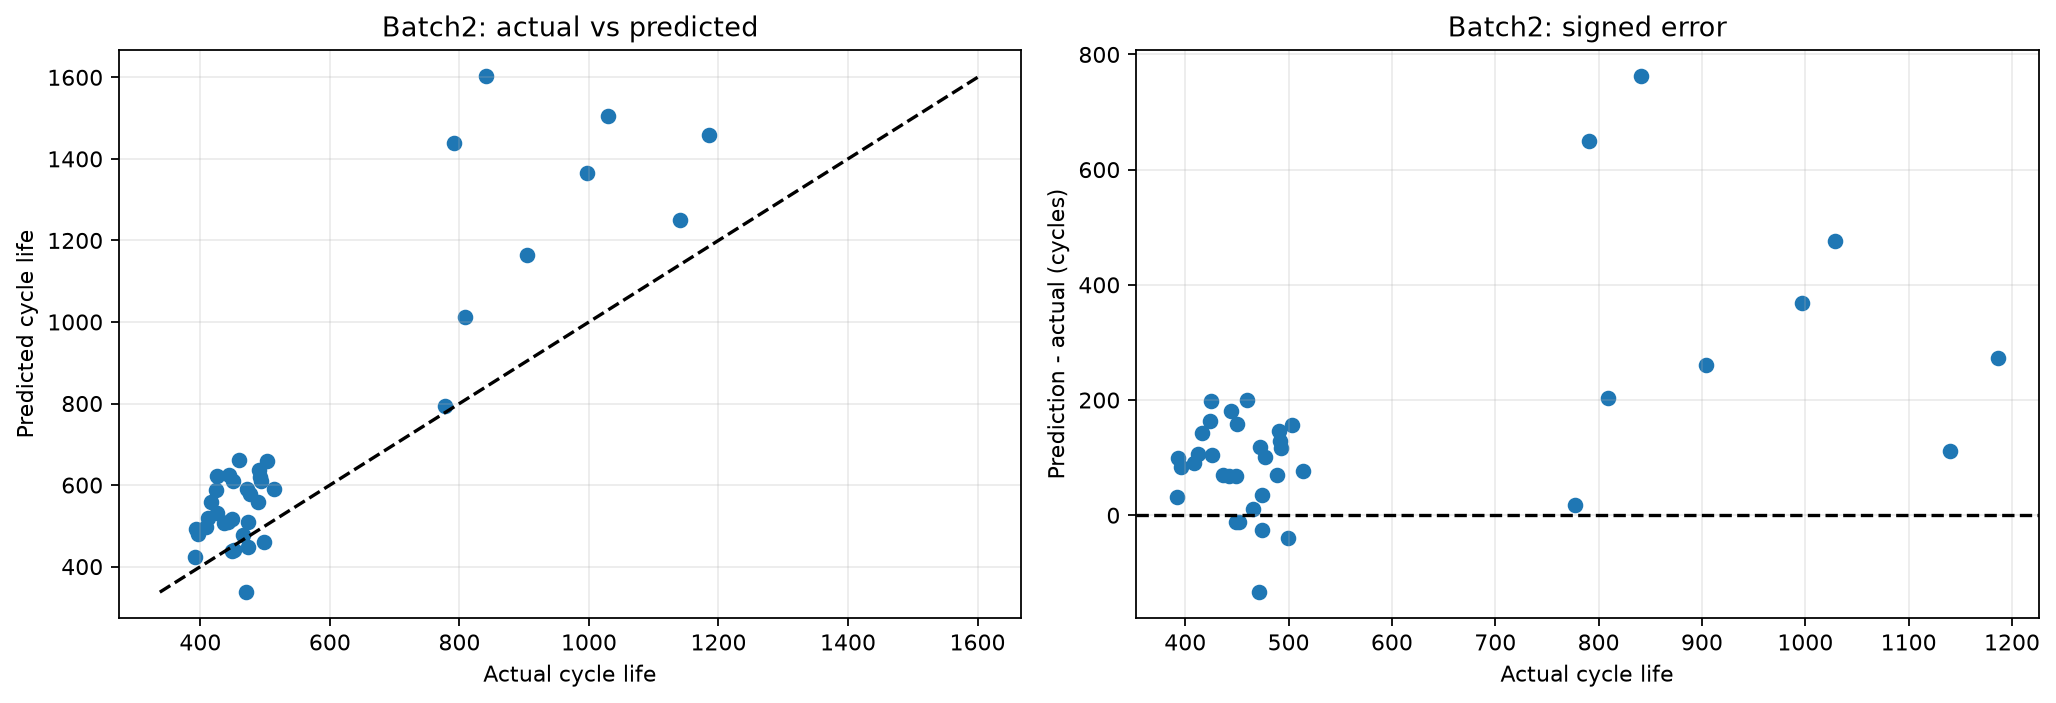

In [11]:
def prediction_table(frame,pred,label):
    cols = list(dict.fromkeys(['batch','cell_id','charging_policy','cycle_life',*chosen_cols]))
    t = frame[cols].copy()
    t['predicted_life'] = pred
    t['error_cycles'] = pred-t.cycle_life
    t['APE_pct'] = np.abs(t.error_cycles)/t.cycle_life*100
    t['outside_B1_life_range'] = ~t.cycle_life.between(b1.cycle_life.min(),b1.cycle_life.max())
    t['outside_B1_feature_range'] = False
    for col in chosen_cols:
        t['outside_B1_feature_range'] |= ~t[col].between(b1[col].min(),b1[col].max())
    t.to_csv(OUT/f'predictions_{label}.csv',index=False)
    return t

hold_errors = prediction_table(hold,hold_pred,'holdout')
test_errors = prediction_table(b2,test_pred,'batch2')
error_sets = [('Batch2',test_errors)]
for label,t in error_sets:
    print(label,'과대예측 비율:',round(t.error_cycles.gt(0).mean()*100,1),'%')
    display(t.sort_values('APE_pct',ascending=False).head(10))
    display(t.groupby('charging_policy').agg(n=('cell_id','size'),MAPE=('APE_pct','mean'),bias=('error_cycles','mean')))
    fig,axs = plt.subplots(1,2,figsize=(13,4.5))
    lo=min(t.cycle_life.min(),t.predicted_life.min());hi=max(t.cycle_life.max(),t.predicted_life.max())
    axs[0].scatter(t.cycle_life,t.predicted_life);axs[0].plot([lo,hi],[lo,hi],'k--')
    axs[0].set(xlabel='Actual cycle life',ylabel='Predicted cycle life',title=f'{label}: actual vs predicted')
    axs[1].scatter(t.cycle_life,t.error_cycles);axs[1].axhline(0,color='black',linestyle='--')
    axs[1].set(xlabel='Actual cycle life',ylabel='Prediction - actual (cycles)',title=f'{label}: signed error')
    for ax in axs: ax.grid(alpha=.25)
    fig.tight_layout();fig.savefig(OUT/f'{label}_errors.png',dpi=160);plt.show()

**오류 해석:** Batch 2 39개 중 34개(87.2%)를 과대예측했고 평균 편향은 +144.25사이클이다. cell 44는 실제 841 → 예측 1,604.33, APE 90.76%; cell 9는 실제 791 → 예측 1,440.14, APE 82.07%다. 두 셀은 학습 수명 범위 안에 있지만 여러 입력 피처는 학습 범위를 벗어난다. 수명 범위만으로 오류를 설명할 수 없다.

## 13 피처 조합과 오류 구간 비교
**역할:** 후보 계열·피처 조합별 최선 CV와 단수명/장수명·학습 범위 안팎 오차를 확인한다. 실제 수명 범위 구분은 평가 후 오류 설명용이다.

최종 모델 CV fold 결과


,model,feature_set,target,CV_MAPE_mean,CV_MAPE_std
0,ElasticNet,B_discharge_adapted,log10,4.775134,1.718035
2,Ridge,B_discharge_adapted,log10,4.993773,1.938976
80,GradientBoosting,A_variance,log10,9.613289,4.125561
97,RandomForest,A_variance,log10,9.999772,3.724455
151,Dummy,A_variance,raw,13.823307,3.719321


,feature_set,target,CV_MAPE_mean,CV_MAPE_std
2,B_discharge_adapted,log10,4.993773,1.938976
8,B_discharge_adapted,raw,5.767391,1.553947
15,C_signals_adapted,log10,6.627083,1.803317
29,C_signals_adapted,raw,8.281636,3.538493
38,A_variance,raw,8.718375,3.109287
44,E_delta_chargetime,raw,8.773879,2.525418
55,A_variance,log10,8.981148,2.903696
67,E_delta_chargetime,log10,9.132324,2.608874
76,D_delta_current,log10,9.425008,2.988654
78,D_delta_current,raw,9.444292,3.162421


,batch,group,cells,MAPE_pct,bias_cycles,overprediction_pct
0,Batch2,Long >1000,3,26.297,286.207,100.000
1,Batch2,Middle 500-1000,8,38.982,311.845,100.000
2,Batch2,Short <500,28,21.761,81.151,82.143
3,Batch2,Inside B1 life range,7,44.602,391.144,100.000
4,Batch2,Outside B1 life range,32,21.495,90.238,84.375


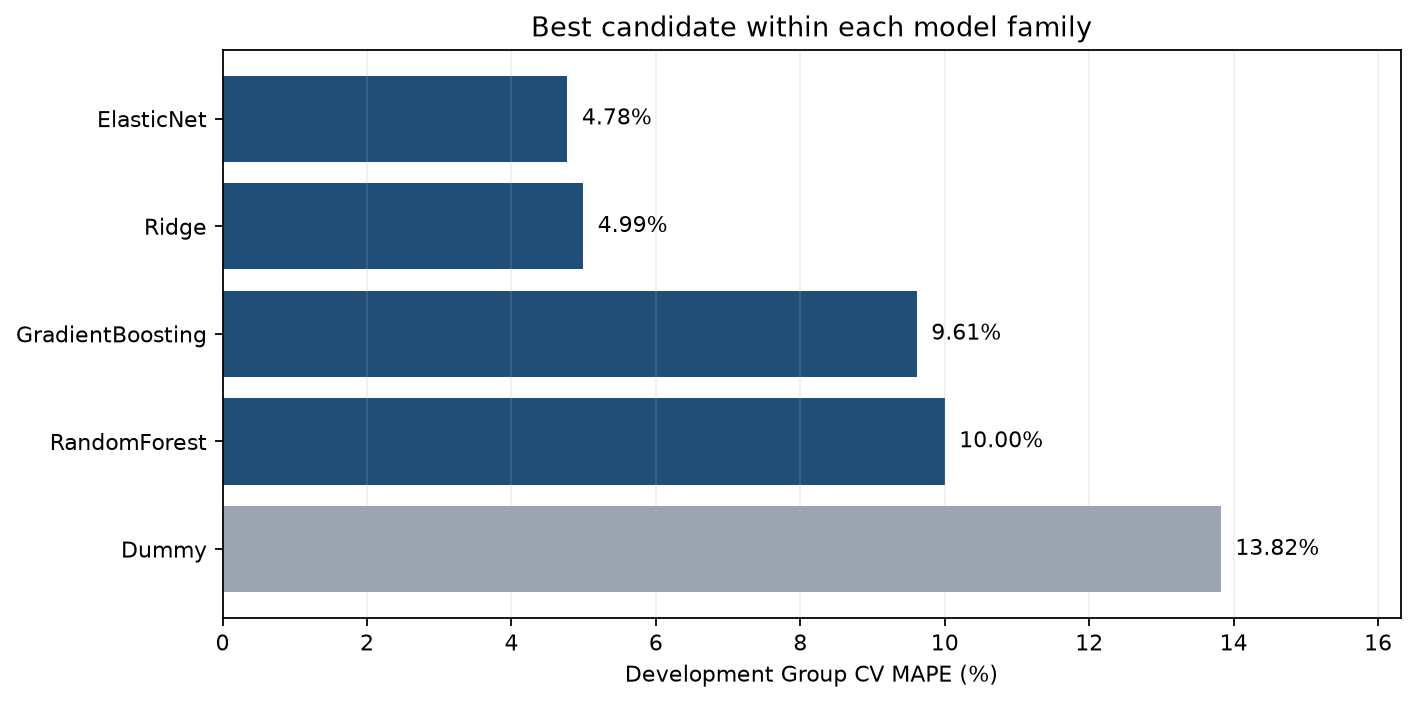

,candidate_id,fold,MAPE_pct,MAE_cycles,RMSE_cycles
212,ElasticNet_B_discharge_adapted_log10_053,1,3.884388,31.449773,41.365643
213,ElasticNet_B_discharge_adapted_log10_053,2,2.915765,23.896853,39.509456
214,ElasticNet_B_discharge_adapted_log10_053,3,5.508836,44.006649,53.947416
215,ElasticNet_B_discharge_adapted_log10_053,4,6.791548,57.580412,70.204302


In [12]:
# 동일 모델 계열 안에서 피처 추가 및 Target 변환 효과를 비교한다.
best_family = cv_results.sort_values('CV_MAPE_mean').groupby('model',sort=False).head(1)
best_combo = cv_results.sort_values('CV_MAPE_mean').groupby(['model','feature_set','target'],sort=False).head(1)
best_family.to_csv(OUT/'best_model_families.csv',index=False)
best_combo.to_csv(OUT/'feature_comparison.csv',index=False)
display(best_family[['model','feature_set','target','CV_MAPE_mean','CV_MAPE_std']])
display(best_combo.loc[best_combo.model=='Ridge',['feature_set','target','CV_MAPE_mean','CV_MAPE_std']])
strata=[]
for label,t in error_sets:
    t=t.copy()
    t['life_group']=np.select([t.cycle_life<500,t.cycle_life>1000],['Short <500','Long >1000'],default='Middle 500-1000')
    for key,g in t.groupby('life_group'):
        strata.append({'batch':label,'group':key,'cells':len(g),'MAPE_pct':g.APE_pct.mean(),'bias_cycles':g.error_cycles.mean(),'overprediction_pct':g.error_cycles.gt(0).mean()*100})
    for key,g in t.groupby('outside_B1_life_range'):
        strata.append({'batch':label,'group':'Outside B1 life range' if key else 'Inside B1 life range','cells':len(g),'MAPE_pct':g.APE_pct.mean(),'bias_cycles':g.error_cycles.mean(),'overprediction_pct':g.error_cycles.gt(0).mean()*100})
strata=pd.DataFrame(strata);strata.to_csv(OUT/'error_by_life_group.csv',index=False)
display(strata.round(3))
fig,ax=plt.subplots(figsize=(9,4.5))
colors=['#1F4E79' if m!='Dummy' else '#9AA5B1' for m in best_family.model]
ax.barh(best_family.model[::-1],best_family.CV_MAPE_mean[::-1],color=colors[::-1])
ax.set(xlabel='Development Group CV MAPE (%)',title='Best candidate within each model family')
for i,v in enumerate(best_family.CV_MAPE_mean[::-1]): ax.text(v+.2,i,f'{v:.2f}%',va='center')
ax.set_xlim(0,best_family.CV_MAPE_mean.max()*1.18);ax.grid(axis='x',alpha=.2)
fig.tight_layout();fig.savefig(OUT/'cv_model_comparison.png',dpi=180);plt.show()
# 실제/예측 그래프에서 오차를 해석한다. 다변수 모델을 ΔQ 하나의 직선으로 표시하지 않는다.
print('최종 모델 CV fold 결과')
display(pd.DataFrame(fold_rows).loc[lambda d:d.candidate_id.eq(chosen_id)])


**구간 해석:** 단수명 28개 MAPE 21.76%, 중간수명 8개 38.98%, 장수명 3개 26.30%다. 학습 수명 범위 안 7개는 44.60%, 범위 밖 32개는 21.50%로, 이전 단일 피처 모델에서의 오류 패턴과 달라졌다. 새로운 오류 결과로 설명을 갱신해야 한다.

## 14 논문 모델과 정량 비교
**역할:** 초록 목표값만 비교하는 데서 끝내지 않고 Table 1의 Variance·Discharge·Full과 MAPE 및 RMSE 차이를 계산한다.
**주의:** 다른 셀·분할·피처 구현이므로 알고리즘 자체의 우열을 증명한 비교가 아니다. 괄호 수치를 우리 오류 셀 삭제의 근거로 사용하지 않는다.

In [13]:
# 본문 Table 1 p.386의 Primary test값. 괄호는 논문의 이상 셀 1개 제외 결과다.
paper=pd.DataFrame([
 {'model':'Paper Variance','train_fit_MAPE':14.1,'primary_MAPE':14.7,'primary_excl1_MAPE':13.2,'primary_RMSE':138,'primary_excl1_RMSE':138},
 {'model':'Paper Discharge','train_fit_MAPE':9.8,'primary_MAPE':13.0,'primary_excl1_MAPE':10.1,'primary_RMSE':91,'primary_excl1_RMSE':86},
 {'model':'Paper Full','train_fit_MAPE':5.6,'primary_MAPE':14.1,'primary_excl1_MAPE':7.5,'primary_RMSE':118,'primary_excl1_RMSE':100},
])
paper['our_Batch2_MAPE']=test_score['MAPE_pct']
paper['our_minus_paper_MAPE_pp']=test_score['MAPE_pct']-paper.primary_MAPE
paper['our_Batch2_RMSE']=test_score['RMSE_cycles']
paper['our_minus_paper_RMSE_cycles']=test_score['RMSE_cycles']-paper.primary_RMSE
paper['comparison_note']='조건이 다른 참고 비교; 원논문 모델 직접 재현 아님'
paper.to_csv(OUT/'paper_model_comparison.csv',index=False)
display(paper.round(3))
# 별도 진단: 논문의 Train fitted error와 과제의 Train CV는 같지 않다.
fit_score=metrics(b1.cycle_life,final_model.predict(b1[chosen_cols]))
display(pd.DataFrame([fit_score],index=['Batch1 training fit diagnostic (NOT Train CV)']))
(OUT/'train_fit_diagnostic.json').write_text(json.dumps(fit_score,indent=2))
# 논문형 Variance 구조의 최선 후보와 최종 모델을 같은 내부 CV로 비교한다.
variance_like=cv_results.loc[(cv_results.model=='ElasticNet')&(cv_results.feature_set=='A_variance')&(cv_results.target=='log10')].iloc[0]
display(variance_like.to_frame('Paper-like variance candidate'))
print('논문 초록 9.1%와 본문 Table 1의 각 모델 수치를 혼동하지 않는다.')


논문 초록 9.1%와 본문 Table 1의 각 모델 수치를 혼동하지 않는다.


,model,train_fit_MAPE,primary_MAPE,primary_excl1_MAPE,primary_RMSE,primary_excl1_RMSE,our_Batch2_MAPE,our_minus_paper_MAPE_pp,our_Batch2_RMSE,our_minus_paper_RMSE_cycles,comparison_note
0,Paper Variance,14.1,14.7,13.2,138,138,25.642,10.942,223.144,85.144,조건이 다른 참고 비교; 원논문 모델 직접 재현 아님
1,Paper Discharge,9.8,13.0,10.1,91,86,25.642,12.642,223.144,132.144,조건이 다른 참고 비교; 원논문 모델 직접 재현 아님
2,Paper Full,5.6,14.1,7.5,118,100,25.642,11.542,223.144,105.144,조건이 다른 참고 비교; 원논문 모델 직접 재현 아님


,MAPE_pct,MAE_cycles,RMSE_cycles
Batch1 training fit diagnostic (NOT Train CV),4.54713,37.341851,48.468433


,Paper-like variance candidate
candidate_id,ElasticNet_A_variance_log10_023
model,ElasticNet
feature_set,A_variance
target,log10
params,"{""alpha"": 0.01, ""l1_ratio"": 0.1}"
CV_MAPE_mean,8.995906
CV_MAPE_std,2.908711
CV_MAE,71.267279
CV_RMSE,85.882436


**논문 비교 해석:** 우리 Batch 2 MAPE 25.642%는 원문 Table 1 기본 Primary test 기준 Variance 14.7%보다 +10.942%p, Discharge 13.0%보다 +12.642%p, Full 14.1%보다 +11.542%p다. RMSE도 각각 +85.14/+132.14/+105.14사이클 높다. 서로 다른 데이터와 분할이므로 직접적인 알고리즘 순위 비교가 아닌 참고 비교다. 괄호 수치는 원문에서 이상 셀 하나를 제외한 결과이며 우리는 39개 셀을 모두 유지했다.

## 15 고정 기준 모델과 입력 분포 진단
**역할:** 논문형 Variance 구조, 기존 ΔQ 단독 Ridge와 중앙값 기준선을 같은 현재 데이터에서 평가해 피처 확장 효과를 비교한다. 이 후보들은 CV에서 정한 설정을 사용하며 테스트로 최종 선택을 변경하지 않는다. 피처의 Batch별 범위와 표준화 계수를 확인한다.

In [14]:
baseline_rows=[]
reference_ids=['Dummy_median',variance_like.candidate_id,
               cv_results.loc[(cv_results.model=='Ridge')&(cv_results.feature_set=='A_variance')&(cv_results.target=='raw')].iloc[0].candidate_id]
for cid in reference_ids:
    spec=spec_by_id[cid];cols=FEATURE_SETS[spec['feature_set']]
    est=make_estimator(spec);est.fit(b1[cols],b1.cycle_life)
    score=metrics(b2.cycle_life,est.predict(b2[cols]))
    baseline_rows.append({'candidate_id':cid,'model':spec['model'],'features':spec['feature_set'],'target':spec['target'],
                          'CV_MAPE':float(cv_results.loc[cv_results.candidate_id.eq(cid),'CV_MAPE_mean'].iloc[0]),**score})
baselines=pd.DataFrame(baseline_rows);baselines.to_csv(OUT/'fixed_reference_comparison.csv',index=False)
display(baselines.round(3))
# 입력 분포 차이: 학습 범위와 테스트 범위를 비교한다. 테스트 통계는 보정에 사용하지 않는다.
shift=[]
for col in chosen_cols:
    shift.append({'feature':col,'B1_min':b1[col].min(),'B1_mean':b1[col].mean(),'B1_max':b1[col].max(),
                  'B2_min':b2[col].min(),'B2_mean':b2[col].mean(),'B2_max':b2[col].max(),
                  'B2_outside_B1_n':int((~b2[col].between(b1[col].min(),b1[col].max())).sum())})
shift=pd.DataFrame(shift);shift.to_csv(OUT/'feature_shift_diagnostics.csv',index=False);display(shift)
pipe=final_model.regressor_ if chosen['target']=='log10' else final_model
if hasattr(pipe.named_steps['model'],'coef_'):
    coef=pd.DataFrame({'feature':chosen_cols,'standardized_coefficient':pipe.named_steps['model'].coef_})
    coef.to_csv(OUT/'model_coefficients.csv',index=False);display(coef)
print('기준 후보는 비교용이며 Batch2 점수로 최종 모델을 교체하지 않았다.')


기준 후보는 비교용이며 Batch2 점수로 최종 모델을 교체하지 않았다.


,candidate_id,model,features,target,CV_MAPE,MAPE_pct,MAE_cycles,RMSE_cycles
0,Dummy_median,Dummy,A_variance,raw,13.823,58.728,284.782,301.423
1,ElasticNet_A_variance_log10_023,ElasticNet,A_variance,log10,8.996,29.014,144.930,163.834
2,Ridge_A_variance_raw_001,Ridge,A_variance,raw,8.718,25.688,129.584,153.225


,feature,B1_min,B1_mean,B1_max,B2_min,B2_mean,B2_max,B2_outside_B1_n
0,delta_q_log_variance,-4.178878,-3.790902,-3.350338,-4.448585,-3.596276,-3.085882,17
1,delta_q_log_abs_min,-1.625407,-1.413760,-1.188960,-1.717991,-1.321401,-1.064745,14
2,qd_cycle2,1.053779,1.077941,1.094639,1.067174,1.093512,1.109278,21
3,qd_max_minus_cycle2,0.003094,0.004859,0.009460,0.000138,0.007054,0.018218,21
4,qd_slope_cycle2_100,-0.000140,-0.000010,0.000029,-0.000195,0.000006,0.000120,18


,feature,standardized_coefficient
0,delta_q_log_variance,-0.000000
1,delta_q_log_abs_min,-0.090730
2,qd_cycle2,0.022047
3,qd_max_minus_cycle2,-0.031821
4,qd_slope_cycle2_100,0.004718


**같은 데이터의 기준선 해석:** 논문형 Variance 아이디어의 Elastic Net+로그 Target은 CV 8.996%, Batch 2 29.014%다. 기존 ΔQ 단독 Ridge는 CV 8.718%, Batch 2 25.688%다. 확장 최종 모델은 CV가 약 3.94%p 좋아졌지만 Batch 2 MAPE 개선은 0.046%p뿐이고 RMSE는 153.23→223.14로 나빠졌다. 최종 모델은 내부 선택 기준의 최적 후보이며 외부 성능 개선에 성공했다고 표현하지 않는다.

**입력/계수 해석:** qd_cycle2는 B1 평균 1.07794 Ah, B2 1.09351 Ah이며 B2 21개가 학습 범위 밖이다. ΔQ 로그분산 17개, 로그 절댓값 최솟값 14개, 최대 증가량 21개, 초기 기울기 18개도 범위 밖이다. 최종 36셀 재학습에서는 ΔQ 로그분산 계수가 0이 되어 5개 후보 중 4개 계수가 0이 아니다. 이는 Elastic Net의 중복 신호 축소 결과이며 ΔQ 분산에 정보가 전혀 없다는 뜻은 아니다. 계수는 표준화 입력→로그 수명의 단위이고 인과계수로 해석하지 않는다.

## 16 결과·모델 저장 검증
**역할:** 저장 모델의 예측 일치, 정책 중복 없음, 최소 CV 후보 선택, 추가 테스트 항목 미포함을 검사한다.

In [15]:
with (OUT/'final_model.pkl').open('rb') as f:restored=cloudpickle.load(f)
np.testing.assert_allclose(restored['estimator'].predict(b2[restored['features']]),test_pred,rtol=1e-12,atol=1e-10)
assert len(hold_errors)==8 and len(test_errors)==39
assert set(dev.cell_id).isdisjoint(set(hold.cell_id))
assert set(dev.charging_policy).isdisjoint(set(hold.charging_policy))
assert np.isfinite(report['MAPE (%)']).all()
assert np.isclose(selected_cv.CV_MAPE_mean,cv_results.CV_MAPE_mean.min())
assert report['구분'].tolist()==['Train (Batch 1 CV)','Valid (Batch 1 Hold-out)','Test (Batch 2)','Gap (Train-Valid)','Gap (Valid-Test)','Gap (Target-Test)']
checks={'data_sha256':DATA_HASH,'summary_hashes':summary_hashes,'seed':SEED,'n_candidates':len(specs),'n_cv_fits':len(fold_rows),'development_cells':len(dev),'holdout_cells':len(hold),'final_train_cells':len(b1),'batch2_cells':len(b2),'policy_overlap':0,'saved_model_predictions_match':True,'cv_minimum_selected':True,'paper_table1_checked':True,'test_history_disclosed':True}
(OUT/'verification.json').write_text(json.dumps(checks,ensure_ascii=False,indent=2))
display(pd.Series(checks,name='검증 결과').to_frame())
print('논문 기반 재분석 검증 완료. 평가 대상은 Batch1 / Batch2만 포함한다.')


논문 기반 재분석 검증 완료. 평가 대상은 Batch1 / Batch2만 포함한다.


,검증 결과
data_sha256,2ced3d4d53acbda49b687555f1e35861085bb470aee42e...
summary_hashes,{'batch1_summary.csv.gz': 'c723e3610988d590c6b...
seed,42
n_candidates,161
n_cv_fits,644
development_cells,28
holdout_cells,8
final_train_cells,36
batch2_cells,39
policy_overlap,0


**검증 해석:** 최소 CV 후보 선택, 정책 겹침 없음, 모델 저장·복원 예측 일치, 성능값 유한성을 확인했다. 입력 데이터·Summary의 해시를 기록했다. 최종 평가에는 요청한 학습·내부 검증과 필수 테스트만 포함한다.

## 17 제출 결론
논문은 초기 방전곡선의 변화와 규제 회귀를 이용한다. 이번 모델은 그 접근을 적용해 로그 수명과 방전 피처 확장 조합을 선택했다. 내부 CV/검증은 개선됐지만 필수 테스트 목표에는 미달했고, 절대오차는 기존 단일 피처 모델보다 커졌다.

논문과 같은 데이터 분할·피처 정의·계수를 사용하지 않았으므로 정확한 재현이라고 주장하지 않는다. 특히 원문의 Train은 적합 오차, 우리 Train은 CV 평균이다. 과제 목표 9.1%와 원문 Table 1 각 모델의 Primary test 수치를 따로 보고한다.

다음 단계는 새 데이터로의 검증, 측정 기준·곡선 정렬 확인, 입력 범위 밖 위험과 과대예측 관리다. 현재 모델은 ESS 정비·교체 시점의 단독 결정 기준으로 쓰기 어렵다. 이미 확인한 테스트 결과에 맞춘 후속 변경은 탐색 결과로 분리한다.


## 16 ESS 운영 목적에 맞춘 추가 평가
**역할:** 교수님 안내에 따라 MAPE·RMSE와 오차 방향을 함께 확인한다. 초기 Ridge와 최종 Elastic Net, 저장된 Voting 예측을 같은 Batch 2 셀에서 비교한다. 최종 모델 선택과 과제 성능표는 변경하지 않는다.

수명을 과대예측하면 예측을 그대로 신뢰했을 때 점검·교체를 늦출 수 있다. 과소예측하면 불필요하게 이른 점검·교체가 발생할 수 있다. 실제 비용이나 고장 확률은 운전·정비 기록이 없어 계산하지 않는다. 아래는 평가 후 오류 진단이며, 새 학습 피처로 사용하지 않는다.


In [16]:
# 교수님 안내 보완: 전체 평균 오차와 수명 과대예측 위험을 함께 평가한다.
# 모델을 새로 선택하거나 테스트 결과에 맞춰 보정하지 않는다.
from pathlib import Path
import json
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error

business_out = ROOT/'output/day2'
x = pd.read_csv(business_out/'model_input_features.csv')
x = x.loc[x.cycle_life.notna() & x.cycle_life.gt(0)].copy()
train_x = x.loc[x.batch.eq('Batch1')]
test_x = x.loc[x.batch.eq('Batch2')]
assert len(train_x)==36 and len(test_x)==39
final_preds = pd.read_csv(business_out/'predictions_batch2.csv')
# 초기 Ridge 설정을 고정해 같은 셀에서 비교한다. 재튜닝하지 않는다.
reference_model = Pipeline([('imputer',SimpleImputer(strategy='median')),
                            ('scaler',StandardScaler()),('ridge',Ridge(alpha=.1))])
reference_model.fit(train_x[['delta_q_log_variance']],train_x.cycle_life)
reference_preds = test_x[['cell_id','cycle_life']].copy()
reference_preds['predicted_life'] = reference_model.predict(test_x[['delta_q_log_variance']])
frames=[('초기 Ridge',reference_preds),('최종 Elastic Net',final_preds)]
ensemble_path = ROOT/'output/day2_ensemble/predictions.csv'
if ensemble_path.exists():
    frozen=json.loads((ROOT/'output/day2_ensemble/selection_frozen.json').read_text())
    ep=pd.read_csv(ensemble_path)
    ep=ep.loc[ep.candidate_id.eq(frozen['best_ensemble']['id']) & ep.dataset.eq('Batch2')]
    ep=ep.rename(columns={'actual':'cycle_life','predicted':'predicted_life'})
    frames.append(('최상위 Voting',ep))

business_rows=[];business_details=[]
for label,t in frames:
    y=t.cycle_life.to_numpy();p=t.predicted_life.to_numpy();e=p-y;a=np.abs(e)/y*100
    assert len(t)==39 and np.isfinite(p).all()
    business_rows.append({'모델':label,'평가셀수':len(t),
       'MAPE_pct':float(a.mean()),'MAE_cycles':float(np.abs(e).mean()),
       'RMSE_cycles':float(np.sqrt(np.mean(e**2))),
       'overprediction_cells':int((e>0).sum()),'overprediction_pct':float((e>0).mean()*100),
       'mean_bias_cycles':float(e.mean()),'max_overprediction_cycles':float(e.max()),
       'median_APE_pct':float(np.median(a)),'p90_APE_pct':float(np.quantile(a,.9))})
    for cid,actual,pred in zip(t.cell_id,y,p):
        business_details.append({'model':label,'cell_id':cid,'actual':actual,'predicted':pred,
                                 'error_cycles':pred-actual,'APE_pct':abs(pred-actual)/actual*100})
business_metrics=pd.DataFrame(business_rows)
business_metrics.to_csv(business_out/'business_evaluation.csv',index=False,encoding='utf-8-sig')
pd.DataFrame(business_details).to_csv(business_out/'business_error_details.csv',index=False)
np.testing.assert_allclose(business_metrics.iloc[0].MAPE_pct,25.688237171127053,rtol=1e-10)
np.testing.assert_allclose(business_metrics.iloc[1].MAPE_pct,25.642498635652842,rtol=1e-10)
display(business_metrics.round(3))
print('편향 = 예측 - 실제. 양수는 실제보다 오래 사용할 수 있다고 예측했다는 뜻이다.')
print('P90 APE는 셀 상대오차의 90백분위수이며 예측 구간이나 신뢰수준 90%가 아니다.')
print('과대예측 비율은 실패 확률이나 안전 인증 지표가 아니다. 운영 비용은 이번 데이터로 계산하지 않았다.')


,모델,평가셀수,MAPE_pct,MAE_cycles,RMSE_cycles,overprediction_cells,overprediction_pct,mean_bias_cycles,max_overprediction_cycles,median_APE_pct,p90_APE_pct
0,초기 Ridge,39,25.688,129.584,153.225,35,89.744,120.214,295.406,29.654,42.185
1,최종 Elastic Net,39,25.642,155.607,223.144,34,87.179,144.247,763.328,24.500,44.106
2,최상위 Voting,39,25.368,154.097,221.458,34,87.179,142.289,764.356,24.316,43.754


편향 = 예측 - 실제. 양수는 실제보다 오래 사용할 수 있다고 예측했다는 뜻이다.
P90 APE는 셀 상대오차의 90백분위수이며 예측 구간이나 신뢰수준 90%가 아니다.
과대예측 비율은 실패 확률이나 안전 인증 지표가 아니다. 운영 비용은 이번 데이터로 계산하지 않았다.


### 결과 해석 및 도메인 한계
최종 Elastic Net의 과대예측은 34/39개(87.18%), 평균 편향은 +144.25사이클, 최대 과대예측은 +763.33사이클이다. 초기 Ridge의 최대 +295.41사이클보다 커졌다. 상대오차 중앙값은 개선됐지만 큰 오차에 민감한 RMSE는 악화되어 평균 MAPE만으로 운영 적합성을 판단하면 안 된다.

**활용 목표:** 검증 후 점검 우선순위와 교체 계획의 참고 신호로 사용할 가능성을 검토한다. 현재 결과로 자동 교체·충전 제어를 정당화하지 않는다. 초기 데이터로 총 Cycle Life를 예측하는 모델이며 날짜별 남은 수명이나 고장 확률을 직접 예측한 것이 아니다.

**Gap 해석:** Hold-out−CV +0.920%p는 제한된 내부 차이, Test−Hold-out +19.948%p는 외부 배치 성능 저하, Test−9.1 +16.542%p는 목표 미달이다. Gap만으로 과적합이나 특정 측정 차이를 원인으로 확정하지 않는다.

**한계:** 작은 표본과 특정 정책 분할, 피처 중복, 라벨 결측, 이미 확인한 Hold-out/Test, 많은 후보를 고른 선택 낙관성이 있다. 실험실 셀의 Cycle Life를 실제 ESS 팩과 달력 수명으로 바로 환산할 수 없다. 신규 운전 데이터·측정 정렬·예측 불확실성·정비 비용을 확보한 뒤 평가해야 한다.
